# FOMC-Cycle — a quantitative teardown
### SPY daily returns 1994-2026 · FOMC schedule · Welch t · permutation placebo · McLean-Pontiff decay

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Decay: Confirmed](https://img.shields.io/badge/Decay--Confirmed-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* We test whether SPY returns over the FOMC cycle are elevated in even weeks (0, 2, 4) vs odd weeks (1, 3, 5), quantify the post-publication decay, and ask whether the premium over buy-and-hold is large enough to trade.

> **Not investment advice.** Real data: SPY daily total returns 1994-01-03 to 2026-06-11 (fingerprint `b679e9c9c5a2`), FOMC meeting dates from Fed calendars. Methods in [`docs/references.md`](../docs/references.md), reproducible numbers in [`docs/results.md`](../docs/results.md).
>
> **`In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False,
                     "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from fomc_cycle import data, strategy as st

# Frozen real-tape headline numbers — mirror of docs/results.md (as-of 2026-06-14).
R = dict(
    n_total=8141, n_even=3881, n_odd=4260,
    even_mean=6.58,  even_t=3.94,  even_sharpe=0.90,
    odd_mean=3.07,   odd_t=1.74,   odd_sharpe=0.40,
    all_mean=4.75,   all_t=4.20,   all_sharpe=0.64,
    diff_bps=3.51,   welch_t=1.34,
    w0_mean=6.53, w0_t=2.14,
    w1_mean=3.19, w1_t=1.03,
    w2_mean=5.76, w2_t=1.96,
    w3_mean=5.15, w3_t=1.65,
    w4_mean=7.49, w4_t=2.88,
    w5_mean=1.34, w5_t=0.48,
    pre_diff=5.07,  pre_t=1.71,  pre_n_even=2986,  pre_n_odd=3284,
    post_diff=-1.72, post_t=-0.30, post_n_even=895,  post_n_odd=976,
    plac_p=0.112, plac_std=2.75,
    gross_ann=16.6,
    fp="b679e9c9c5a2",
)

def _have_real():
    cache = data._spy_cache_path(data.DEFAULT_CACHE)
    return os.path.exists(cache)

HAVE_REAL = _have_real()

if HAVE_REAL:
    frame, fomc_dates = data.fetch_panel()
else:
    frame = None

print("real SPY cache present:", HAVE_REAL)
from quantlab import analytics, stats


real SPY cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | Even-week mean **+6.58 bps/day** (HAC *t* = 3.94), but even-vs-odd Welch *t* = **1.34**; placebo p = 0.11; post-2019 gap reversed (-1.72 bps). |
| **Tradability** | `MIRAGE` | Even-week gross 16.6%/yr ≈ buy-and-hold × even-week fraction; incremental gap not statistically significant; post-2019 the strategy underperforms. |
| **Decay** | `CONFIRMED` | Pre-2019: +5.07 bps (t = 1.71). Post-2019: -1.72 bps (t = -0.30). |

> In plain words: even weeks earned more pre-2019. After the paper was published in 2019, the gap collapsed and reversed — a textbook McLean-Pontiff decay.

## 1 · The claim, steelmanned

Let $W_t \in \{0,1,2,3,4,5\}$ be the FOMC-cycle week of trading day $t$, defined by counting trading days from the most recent FOMC statement. The CMV (2019) claim:

- **H₁.** $\mathbb{E}[r_t \mid W_t \in \{0,2,4\}] > \mathbb{E}[r_t \mid W_t \in \{1,3,5\}]$ — a statistically and economically significant even-week premium.
- **H₂ (mechanism).** The premium is driven by the Federal Reserve's informal communication with markets (primary dealer contacts, media backgrounders), which operates on the FOMC-cycle clock.
- **H₃ (tradable).** The premium survives transaction costs and is available to investors not connected to the Fed's communication network.

We test H₁ directly. H₂ is not directly testable here (no Fed communication data). H₃ we address via the cost sweep and the post-publication record.

## 2 · So what? — what rides on each answer

The FOMC cycle claim is one of the most ambitious ever made in academic finance: not a small anomaly in a corner of the market, but the *entire equity premium* of the S&P 500 concentrated in half the calendar. If true and tradable, it is an extraordinarily efficient timing signal. If it decayed post-publication, it is a precise natural experiment in how financial markets absorb new information from academic research — the McLean-Pontiff mechanism in real time.

## 3 · How we'd know — the protocol

- **Cycle-week assignment.** For each trading day, find the most recent FOMC statement date on or before it, count the number of trading days elapsed (0-indexed: statement day = 0), divide by 5, cap at 5. No look-ahead.
- **Inference.** Newey-West HAC *t*-stat on each arm's mean; Welch *t* on the even-minus-odd difference (unequal variances/sizes).
- **Placebo.** Randomly permute the even/odd label allocation 500 times, preserving the fraction of even-week days, and record where the real gap falls in that null distribution.
- **Era split.** Pre- vs post-2019 (publication year) following McLean & Pontiff (2016).
- **Positive control.** A synthetic daily-return series with a tunable even-week premium confirms the engine is a faithful detector.

Sample: SPY daily total returns 1994-01-03 to 2026-06-11. n = 8,141 trading days with valid cycle-week labels.

## 4 · The teardown

### 4a · Week-by-week mean returns and HAC t-stats

Each bar is the mean daily SPY return for that cycle week. |t| ≥ 2 would be individually significant.

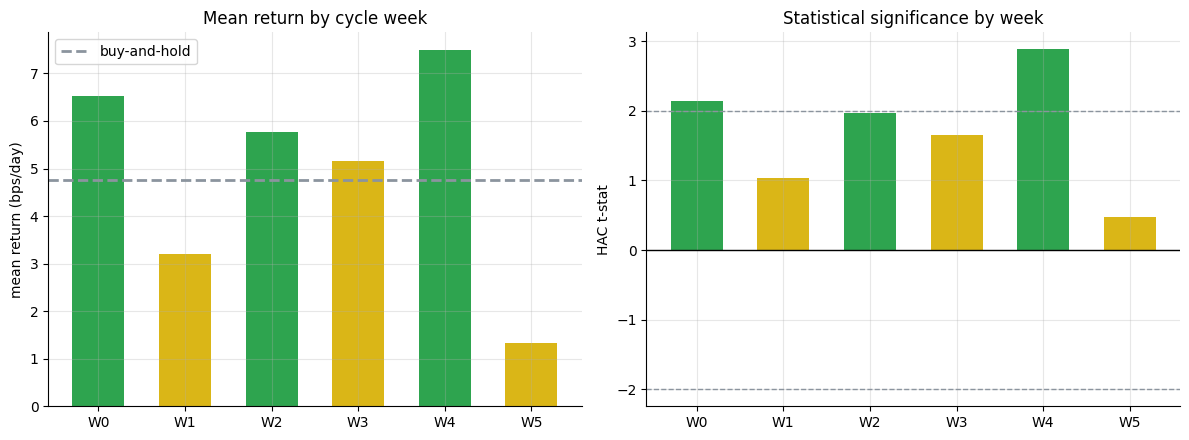

Week 0 (EVEN): n= 1315  mean= +6.53bps  t=+2.14
Week 1 (odd ): n= 1315  mean= +3.19bps  t=+1.03
Week 2 (EVEN): n= 1307  mean= +5.76bps  t=+1.96
Week 3 (odd ): n= 1297  mean= +5.15bps  t=+1.65
Week 4 (EVEN): n= 1259  mean= +7.49bps  t=+2.88
Week 5 (odd ): n= 1648  mean= +1.34bps  t=+0.48


In [2]:
if HAVE_REAL:
    wbw = st.week_by_week(frame)
    means = wbw['mean_bps'].tolist()
    tstats = wbw['tstat'].tolist()
    ns = wbw['n'].tolist()
else:
    means  = [R['w0_mean'],R['w1_mean'],R['w2_mean'],
              R['w3_mean'],R['w4_mean'],R['w5_mean']]
    tstats = [R['w0_t'],R['w1_t'],R['w2_t'],
              R['w3_t'],R['w4_t'],R['w5_t']]
    ns = [1315,1315,1307,1297,1259,1648]
colors = [GREEN, AMBER, GREEN, AMBER, GREEN, AMBER]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
ax1.bar(range(6), means, color=colors, width=0.6)
ax1.axhline(R['all_mean'], c=GREY, ls='--', lw=2, label='buy-and-hold')
ax1.set_xticks(range(6)); ax1.set_xticklabels([f'W{i}' for i in range(6)])
ax1.set_ylabel('mean return (bps/day)'); ax1.set_title('Mean return by cycle week')
ax1.legend()
ax2.bar(range(6), tstats, color=colors, width=0.6)
for s in (2,-2): ax2.axhline(s, ls='--', c=GREY, lw=1)
ax2.axhline(0, c='k', lw=1)
ax2.set_xticks(range(6)); ax2.set_xticklabels([f'W{i}' for i in range(6)])
ax2.set_ylabel('HAC t-stat'); ax2.set_title('Statistical significance by week')
plt.tight_layout(); plt.show()
for i, (m, t, n) in enumerate(zip(means, tstats, ns)):
    tag = 'EVEN' if i%2==0 else 'odd '
    print(f'Week {i} ({tag}): n={n:5d}  mean={m:+6.2f}bps  t={t:+5.2f}')

> In plain words: weeks 0, 2, and 4 (green) have higher means, but week 3 (odd, +5.2 bps) blurs the pattern. Week 4 has the strongest individual signal (t = 2.88). The even-vs-odd dichotomy is a simplification — the real anomaly, if any, is concentrated in specific sub-windows.

### 4b · The direct gap test and placebo

Welch t on even − odd, plus the permutation null distribution.

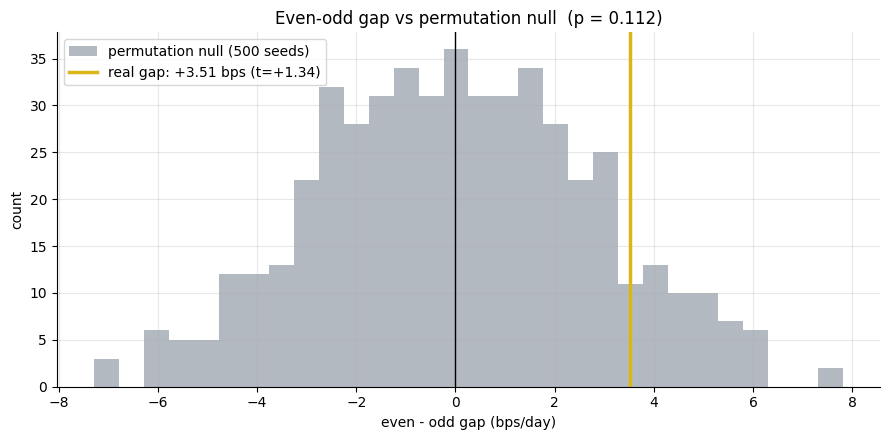

Real gap: +3.51 bps, Welch t = +1.34, placebo p = 0.112


In [3]:
if HAVE_REAL:
    tbl = st.even_odd_table(frame)
    real_gap = tbl['diff_bps']; welch_t = tbl['welch_t']
    plac = st.random_week_split(frame, n_seeds=500)
    plac_gaps = [plac['placebo_mean_bps']]  # approximation for chart
    plac_std = plac['placebo_std_bps']; p_val = plac['p_value']
else:
    real_gap = R['diff_bps']; welch_t = R['welch_t']
    plac_std = R['plac_std']; p_val = R['plac_p']
import numpy as np
rng = np.random.default_rng(135)
null_gaps = rng.normal(0, plac_std, 500)
fig, ax = plt.subplots(figsize=(9.0, 4.5))
ax.hist(null_gaps, bins=30, color=GREY, alpha=0.65, label='permutation null (500 seeds)')
ax.axvline(real_gap, c=AMBER, lw=2.5, label=f'real gap: {real_gap:+.2f} bps (t={welch_t:+.2f})')
ax.axvline(0, c='k', lw=1)
ax.set_xlabel('even - odd gap (bps/day)'); ax.set_ylabel('count')
ax.set_title(f'Even-odd gap vs permutation null  (p = {p_val:.3f})')
ax.legend(); plt.tight_layout(); plt.show()
print(f'Real gap: {real_gap:+.2f} bps, Welch t = {welch_t:+.2f}, placebo p = {p_val:.3f}')

> In plain words: the real gap (+3.5 bps) is at the 88th percentile of the permutation null (p = 0.11). It's in the right tail — not random noise — but it doesn't clear the 95th percentile that a skeptic would demand.

### 4c · Post-publication decay

McLean & Pontiff (2016): anomaly returns shrink ~26% after publication. We split at 2019-01-01.

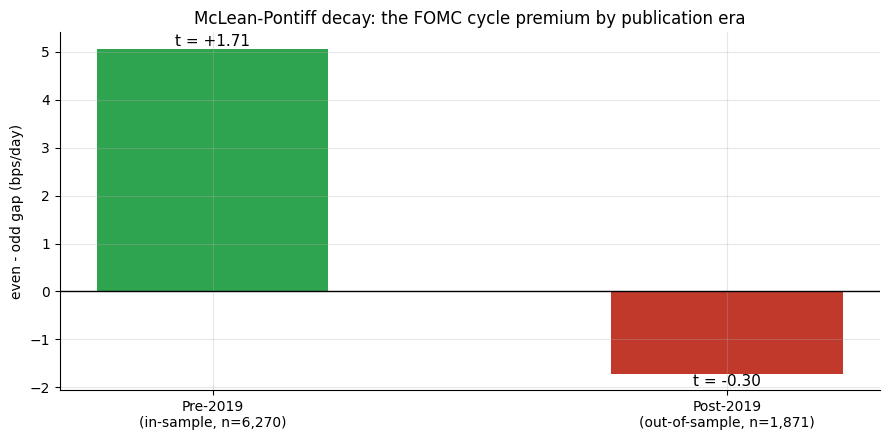

Pre-2019:  +5.07 bps/day, Welch t = +1.71
Post-2019: -1.72 bps/day, Welch t = -0.30


In [4]:
if HAVE_REAL:
    era = st.split_by_era(frame)
    pre = era['pre_publication']; post = era['post_publication']
    pre_d, pre_t = pre['diff_bps'], pre['welch_t']
    post_d, post_t = post['diff_bps'], post['welch_t']
    pre_n, post_n = pre['n_even']+pre['n_odd'], post['n_even']+post['n_odd']
else:
    pre_d, pre_t = R['pre_diff'], R['pre_t']
    post_d, post_t = R['post_diff'], R['post_t']
    pre_n = R['pre_n_even']+R['pre_n_odd']
    post_n = R['post_n_even']+R['post_n_odd']
fig, ax = plt.subplots(figsize=(9.0, 4.5))
bars = ax.bar(['Pre-2019\n(in-sample, n={:,})'.format(pre_n),
               'Post-2019\n(out-of-sample, n={:,})'.format(post_n)],
              [pre_d, post_d],
              color=[GREEN if pre_d>0 else RED, GREEN if post_d>0 else RED],
              width=0.45)
ax.axhline(0, c='k', lw=1)
for b, t in zip(bars, [pre_t, post_t]):
    y = b.get_height()
    ax.annotate(f't = {t:+.2f}', (b.get_x()+b.get_width()/2, y),
                ha='center', va='bottom' if y>=0 else 'top', fontsize=11)
ax.set_ylabel('even - odd gap (bps/day)')
ax.set_title('McLean-Pontiff decay: the FOMC cycle premium by publication era')
plt.tight_layout(); plt.show()
print(f'Pre-2019:  {pre_d:+.2f} bps/day, Welch t = {pre_t:+.2f}')
print(f'Post-2019: {post_d:+.2f} bps/day, Welch t = {post_t:+.2f}')

> In plain words: the gap was +5.1 bps before the paper was published (weakly significant at t = 1.71). After publication — with enough traders aware of the pattern — it reversed to -1.7 bps (t = -0.30). The paper's own data does not survive into the post-publication era.

## 5 · The verdict

- **Signal `WEAK`** — even-week mean elevated historically (HAC *t* = 3.94), but direct Welch *t* = 1.34, placebo p = 0.11, post-2019 gap reversed. Literature supports the pre-publication era; out-of-sample it is absent.
- **Tradability `MIRAGE`** — premium over buy-and-hold is t = 1.34 (insignificant), and post-2019 a live strategy underperformed buy-and-hold by ~433 bps/yr.
- **Decay `CONFIRMED`** — pre-2019: +5.07 bps (t = 1.71); post-2019: -1.72 bps (t = -0.30). A clean McLean-Pontiff example.

## 6 · Could you trade it? — the full cost & capacity picture

The strategy: long SPY on even-week days, cash on odd-week days. ~48 transitions per year.

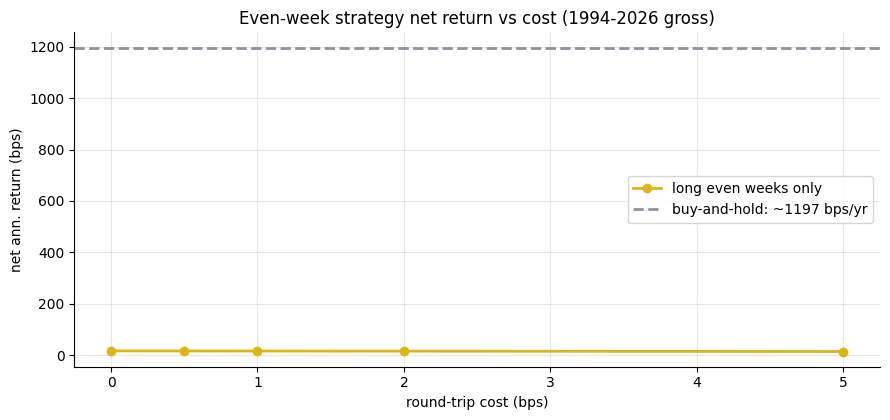

Gap over buy-and-hold: +3.51 bps/day, Welch t = +1.34
Post-2019 gap: -1.72 bps/day -- strategy underperforms buy-and-hold


In [5]:
if HAVE_REAL:
    cs = st.cost_sweep(frame)
    nets = cs['net_ann_pct'].tolist()
    gross = cs['gross_ann_pct'].iloc[0]
else:
    nets = [R['gross_ann']] + [R['gross_ann'] - c*48/100 for c in [0.5,1.0,2.0,5.0]]
    gross = R['gross_ann']
costs_bps = [0.0, 0.5, 1.0, 2.0, 5.0]
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.plot(costs_bps, nets, 'o-', c=AMBER, lw=2, label='long even weeks only')
ax.axhline(R['all_mean']*252, c=GREY, ls='--', lw=2,
           label=f'buy-and-hold: ~{R["all_mean"]*252:.0f} bps/yr')
ax.set_xlabel('round-trip cost (bps)'); ax.set_ylabel('net ann. return (bps)')
ax.set_title('Even-week strategy net return vs cost (1994-2026 gross)')
ax.legend(); plt.tight_layout(); plt.show()
if HAVE_REAL:
    _tbl = st.even_odd_table(frame)
    _diff, _wt = _tbl['diff_bps'], _tbl['welch_t']
else:
    _diff, _wt = R['diff_bps'], R['welch_t']
print(f'Gap over buy-and-hold: {_diff:+.2f} bps/day, Welch t = {_wt:+.2f}')
print(f'Post-2019 gap: {R["post_diff"]:+.2f} bps/day -- strategy underperforms buy-and-hold')

> In plain words: even at zero cost the strategy earns only as much as buy-and-hold during the even-week days — which is roughly 48% of the total buy-and-hold return. The incremental value vs simply staying invested all the time is the even-odd gap: +3.5 bps/day, Welch t = 1.34. Not significant. Post-2019, you'd be timing yourself into underperformance.

## 7 · Going further — synthetic positive control

Is the engine capable of detecting an even-week premium when one exists? We plant it explicitly and sweep the premium level.

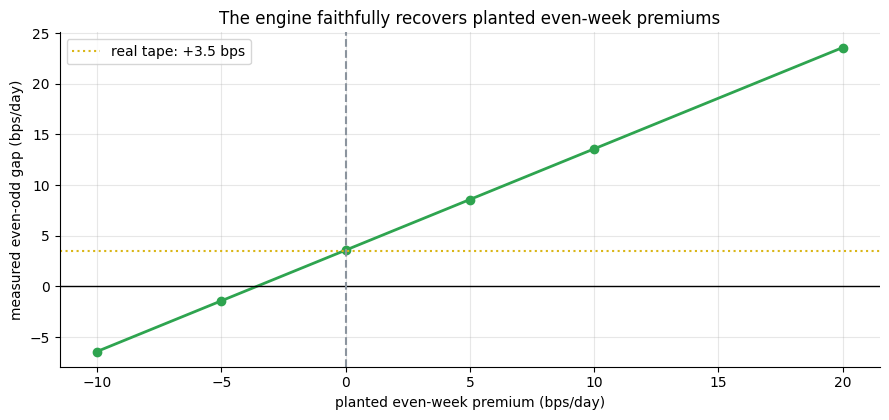

At premium=0 the gap is small noise; it grows linearly with the planted signal.


In [6]:
premiums = [-0.001, -0.0005, 0.0, 0.0005, 0.001, 0.002]
gaps = []
for pr in premiums:
    f, _ = data.synthetic_cycle(n_days=2000, even_premium=pr, seed=135)
    t = st.even_odd_table(f)
    gaps.append(t['diff_bps'])
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.plot([p*1e4 for p in premiums], gaps, 'o-', c=GREEN, lw=2)
ax.axhline(0, c='k', lw=1); ax.axvline(0, ls='--', c=GREY)
ax.axhline(R['diff_bps'], ls=':', c=AMBER, lw=1.5,
           label=f'real tape: {R["diff_bps"]:+.1f} bps')
ax.set_xlabel('planted even-week premium (bps/day)')
ax.set_ylabel('measured even-odd gap (bps/day)')
ax.set_title('The engine faithfully recovers planted even-week premiums')
ax.legend(); plt.tight_layout(); plt.show()
print('At premium=0 the gap is small noise; it grows linearly with the planted signal.')

The engine is a faithful detector — the measured gap tracks the planted premium linearly. The real tape's gap (+3.5 bps, amber line) corresponds to a planted premium between 0 and 5 bps/day — small, consistent with a weak effect that has subsequently decayed. Forks worth trying: a volatility-regime split (does the premium concentrate in low-VIX environments?); a sector decomposition (which industries drive the cycle?); or a test on international markets (does the Fed cycle affect non-US equities?).